# Profitability & Sales Optimization

## Problem Statement:

## Despite a high volume of overall orders, the company lacks visibility into which specific product lines and customer regions are driving true profitability versus just revenue. This dashboard aims to identify our most and least profitable segments to optimize future marketing and pricing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as sa
import pyodbc 
import datetime as dt

In [2]:
connection_string = (
    "mssql+pyodbc://@"
    "OMKAR\\SQLEXPRESS/"
    "DataWarehouse"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&Trusted_Connection=yes"
)

In [3]:
from sqlalchemy import create_engine, text

server = 'localhost\\SQLEXPRESS'
database = 'DataWarehouse'      

connection_url = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&Trusted_Connection=yes"

engine = create_engine(connection_url)

with engine.connect() as connection:
    print("Connected successfully!")

Connected successfully!


In [4]:
query  = '''
		SELECT 
			c.customer_key,
			c.first_name,
			c.last_name,
			c.country,
			c.marital_status,
			c.gender,
			c.birthdate,
			p.product_key,
			p.product_name,
			p.category,
			p.subcategory,
			p.maintenance,
			p.product_cost,
			p.product_line,
			p.start_date,
			s.order_number,
			s.order_date,
			s.shipping_date,
			s.due_date,
			s.price,
			s.quantity,
			s.sales_amount
		FROM gold.fact_sales AS s
		LEFT JOIN gold.dim_customers AS c
		ON s.customer_key = c.customer_key
		LEFT JOIN gold.dim_products AS p
		ON s.product_key = p.product_key;
''' 
df = pd.read_sql(query,con=engine)

In [5]:
df['gender'][df['gender'] == 'n/a'].count()

np.int64(33)

In [6]:
df['country'][df['country'] == 'n/a'].count()

np.int64(871)

### Feature Engineering

In [7]:
df['total_cost'] = df['product_cost'] * df['quantity']
df['total_profit'] = df['sales_amount'] - df['total_cost']
df['profit_margin%'] = df['total_profit'] / df['sales_amount']

### Who are our most profitable customers? What percentage of our total profit comes from our top 10% of customers (High M)?

In [8]:
# Who are our most profitable customers?
print('Top 5 most profitable customers.')

profitable_customers = df.groupby(['customer_key','first_name','last_name'])[['total_profit','profit_margin%']].sum().reset_index()
top_customers = profitable_customers.sort_values(by='total_profit', ascending=False)
print(top_customers.head(5))

# What percentage of our total profit comes from our top 10% of customers (High M)?

overall_profit = profitable_customers['total_profit'].sum()

top_10_per_count = int(len(top_customers)* 0.10)
top_profit_sum = top_customers.head(top_10_per_count)['total_profit'].sum()

profit_contribution = (top_profit_sum / overall_profit) * 100

print(f'\n Profit contribution of top 10% customers {profit_contribution:.2f}')


Top 5 most profitable customers.
      customer_key first_name  last_name  total_profit  profit_margin%
1132          1133    Kaitlyn  Henderson          5274        7.716946
1308          1309   Margaret         He          5254        7.200297
1301          1302    Nichole       Nara          5250        6.476252
1300          1301    Adriana   Gonzalez          5236        5.101855
1131          1132    Randall  Dominguez          5231        5.185578

 Profit contribution of top 10% customers 41.21


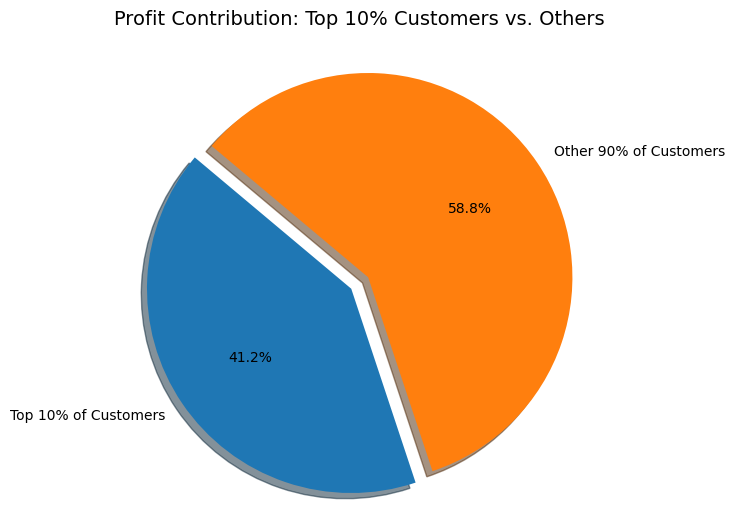

In [9]:
top_10_profit = top_customers.iloc[:top_10_per_count]['total_profit'].sum()
others_profit = top_customers.iloc[top_10_per_count:]['total_profit'].sum()
labels = ['Top 10% of Customers', 'Other 90% of Customers']
sizes = [top_10_profit, others_profit]
explode = (0.1, 0)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels,autopct='%1.1f%%',shadow=True, startangle=140)

plt.title('Profit Contribution: Top 10% Customers vs. Others', fontsize=14, pad=20)
plt.axis('equal') 

# Render the chart
plt.show()

### Are high-revenue customers actually profitable? Are there customers who spend a lot of total money, but mostly buy low-margin products, resulting in a low true profitability score?

In [10]:
## Are high-revenue customers actually profitable?

customer_metric = df.groupby(['customer_key','first_name','last_name']).agg(
        total_revenue = ('sales_amount','sum'),
        total_profit = ('total_profit','sum')
    ).reset_index()

customer_metric['effective_margin'] = (customer_metric['total_profit'] / customer_metric['total_revenue'] * 100 )

customer_metric['revenue_rank'] = customer_metric['total_revenue'].rank(ascending=False,method='min')

customer_metric['profit_rank'] = customer_metric['total_profit'].rank(ascending=False,method='min')

customer_metric['rank_penalty'] = customer_metric['profit_rank'] - customer_metric['revenue_rank']

top_revenue_customers = customer_metric[customer_metric['revenue_rank'] <= 100]

worst_offenders = customer_metric[(customer_metric['revenue_rank'] <= 100) & (customer_metric['rank_penalty'] > 0)].sort_values(by='rank_penalty', ascending=False)

worst_offenders_in_top_revenue_customers = top_revenue_customers[top_revenue_customers['rank_penalty'] > 0]

percetage_of_high_revenue_low_profit_cust = (worst_offenders['customer_key'].count() / customer_metric['customer_key'].count()) * 100

percetage_of_high_revenue_low_profit_in_top_revenue_customers = (worst_offenders_in_top_revenue_customers['customer_key'].count() / top_revenue_customers['customer_key'].count()) *100

print(f"High Revenue, Low Profit Customers do exists but the are {percetage_of_high_revenue_low_profit_cust:.2f}% of Total customers")

print(f"High Revenue, Low Profit Customers do exists but the are {percetage_of_high_revenue_low_profit_in_top_revenue_customers:.2f}% of Top {top_revenue_customers['customer_key'].count()} revenue customers")
customer_metric

High Revenue, Low Profit Customers do exists but the are 0.31% of Total customers
High Revenue, Low Profit Customers do exists but the are 57.00% of Top 100 revenue customers


,customer_key,first_name,last_name,total_revenue,total_profit,effective_margin,revenue_rank,profit_rank,rank_penalty
0,1,Jon,Yang,8249,3513,42.586980,93.0,67.0,-26.0
1,2,Eugene,Huang,6384,2795,43.781328,672.0,429.0,-243.0
2,3,Ruben,Torres,8114,3455,42.580725,201.0,159.0,-42.0
3,4,Christy,Zhu,8139,3466,42.585084,173.0,138.0,-35.0
4,5,Elizabeth,Johnson,8196,3502,42.728160,119.0,73.0,-46.0
...,...,...,...,...,...,...,...,...,...
18479,18480,Tommy,Tang,2049,797,38.897023,5834.0,5735.0,-99.0
18480,18481,Nina,Raji,2442,935,38.288288,4896.0,4878.0,-18.0
18481,18482,Ivan,Suri,3375,1477,43.762963,3538.0,3052.0,-486.0
18482,18483,Clayton,Zhang,2049,797,38.897023,5834.0,5735.0,-99.0


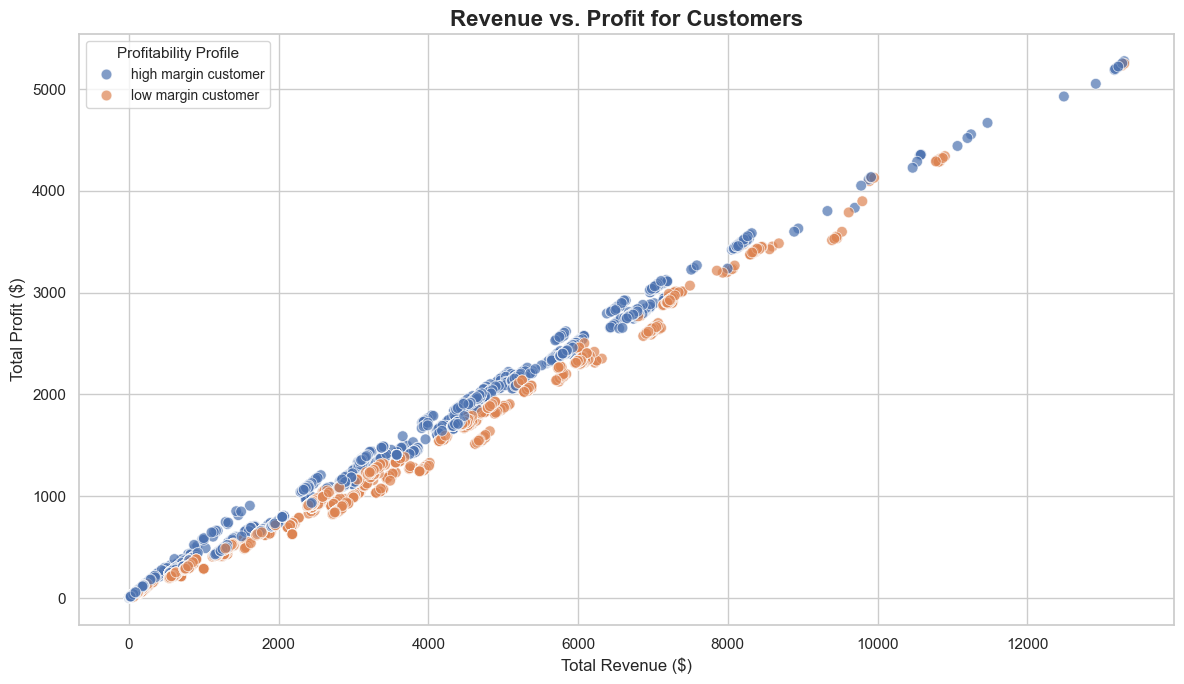

In [11]:
cus_df= customer_metric.copy()

cus_df['customer_type'] = cus_df['rank_penalty'].apply(
    lambda x: 'low margin customer' if x > 0 else 'high margin customer'
)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,7))

sns.scatterplot(data=cus_df, x='total_revenue', y= 'total_profit',hue='customer_type',s=60, alpha = 0.7)

# Add titles and labels
plt.title('Revenue vs. Profit for Customers', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)

# Adjust the legend
plt.legend(title='Profitability Profile', title_fontsize='11', fontsize='10', loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

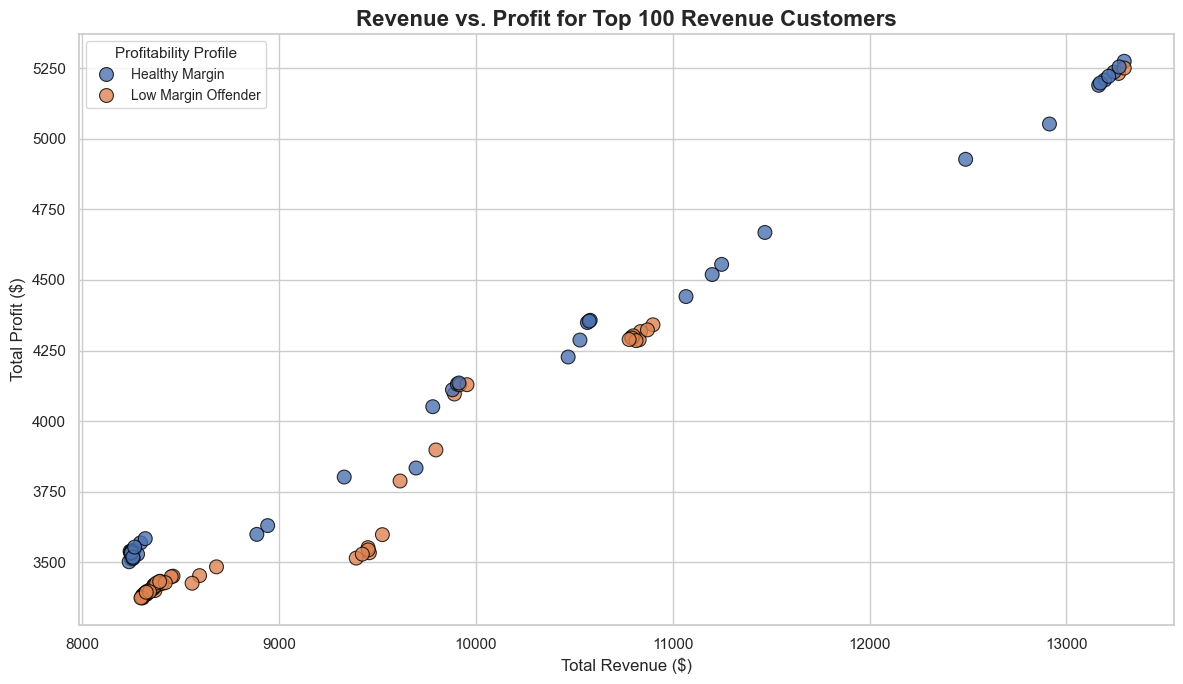

In [12]:
top_100_df = top_revenue_customers.copy()

top_100_df['Customer Type'] = top_100_df['rank_penalty'].apply(
    lambda x: 'Low Margin Offender' if x > 0 else 'Healthy Margin'
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(data=top_100_df, x='total_revenue', y='total_profit', hue='Customer Type', s=100, alpha=0.8, edgecolor='black')

plt.title('Revenue vs. Profit for Top 100 Revenue Customers', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)

plt.legend(title='Profitability Profile', title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()
plt.show()

### Which product lines are "Revenue Illusions"? Which product categories or subcategories generate the top 20% of total revenue but fall into the bottom 50% for profit margin?

In [68]:
product_line_metric =df.groupby(['product_line','category', 'subcategory', 'product_name']).agg(
    total_revenue = ('sales_amount','sum'),
    total_profit = ('total_profit','sum'),
    total_quantity = ('quantity', 'sum'),
    total_product_cost = ('product_cost','sum')
).reset_index()

product_line_metric['effective_margin'] = (product_line_metric['total_profit'] / product_line_metric['total_revenue'] * 100 )

product_line_metric['Revenue_pct_rank'] = product_line_metric['total_revenue'].rank(ascending=False, method='min', pct=True)

product_line_metric['margin_pct_rank'] = product_line_metric['effective_margin'].rank(ascending=False,method='min', pct=True)

revenue_illusion = product_line_metric[
    (product_line_metric['Revenue_pct_rank'] <= 0.20) &
    (product_line_metric['margin_pct_rank'] <= 0.50)
]

columns_to_show = [
    'product_line', 
    'category', 
    'subcategory', 
    'product_name', 
    'total_revenue', 
    'effective_margin'
]
 
revenue_illusion_result = revenue_illusion[columns_to_show].sort_values(by='total_revenue', ascending=False)

revenue_illusion_result


,product_line,category,subcategory,product_name,total_revenue,effective_margin
17,Mountain,Bikes,Mountain Bikes,Mountain-200 Black- 46,1373454,43.482636
16,Mountain,Bikes,Mountain Bikes,Mountain-200 Black- 42,1363128,43.605589
18,Mountain,Bikes,Mountain Bikes,Mountain-200 Silver- 38,1339394,43.665867
20,Mountain,Bikes,Mountain Bikes,Mountain-200 Silver- 46,1301029,43.561596
15,Mountain,Bikes,Mountain Bikes,Mountain-200 Black- 38,1294854,43.726165
19,Mountain,Bikes,Mountain Bikes,Mountain-200 Silver- 42,1257368,43.615552
44,Road,Bikes,Road Bikes,Road-150 Red- 48,1205786,39.323644
47,Road,Bikes,Road Bikes,Road-150 Red- 62,1202208,39.323644
45,Road,Bikes,Road Bikes,Road-150 Red- 52,1080556,39.323644
46,Road,Bikes,Road Bikes,Road-150 Red- 56,1055510,39.323644


### Who are the hidden gems (High Margin in 20%, Low Volume in 10%)? Are there specific product_names or subcategory items that have exceptional profit margins but low overall quantity sold?

In [66]:
product_line_metric['volume_pct_rank'] = product_line_metric['total_quantity'].rank(ascending=False,method='min',pct=True)

hidden_gems = product_line_metric[
    (product_line_metric['margin_pct_rank'] <= 0.10) & 
    (product_line_metric['volume_pct_rank'] >= 0.80)
]

columns_to_show = [
    'product_line', 
    'category', 
    'subcategory', 
    'product_name', 
    'total_quantity', 
    'effective_margin'
]

hidden_gems_result = hidden_gems[columns_to_show].sort_values(by='effective_margin',ascending=False)
hidden_gems_result

,product_line,category,subcategory,product_name,total_quantity,effective_margin


### How does product cost impact the bottom line? Is there a correlation between higher product_cost items and tighter profit margins, or are we successfully passing those costs to the customer?

In [74]:
correlation_metric = product_line_metric[['total_product_cost','effective_margin']].corr(method='spearman')

correlation_metric

,total_product_cost,effective_margin
total_product_cost,1.000000,-0.546666
effective_margin,-0.546666,1.000000


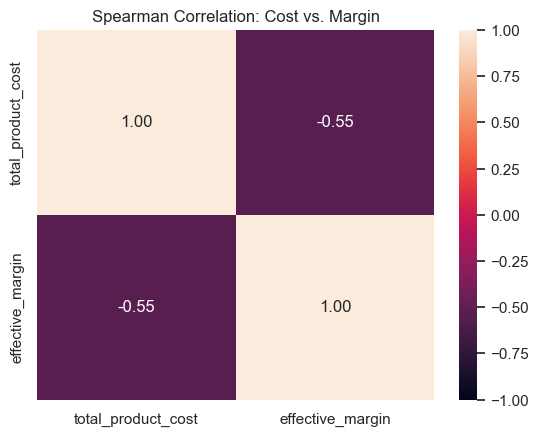

In [89]:
plt.title('Spearman Correlation: Cost vs. Margin')
sns.heatmap(correlation_metric, annot=True, fmt = '.2f', vmin=-1, vmax= 1)
plt.show()

### Does the maintenance flag/cost cannibalize product profitability? How do products requiring maintenance compare in lifetime profit margin against those that do not?

In [98]:
maintenance_metric = df.groupby('maintenance').agg(
    total_profit = ('total_profit','sum'),
    total_revenue = ('sales_amount', 'sum')
)
maintenance_metric['effective_margin'] = (maintenance_metric['total_profit'] / maintenance_metric['total_revenue']) * 100
maintenance_metric

,total_profit,total_revenue,effective_margin
maintenance,,,
No,251421,523277,48.047401
Yes,11434336,28832973,39.657152


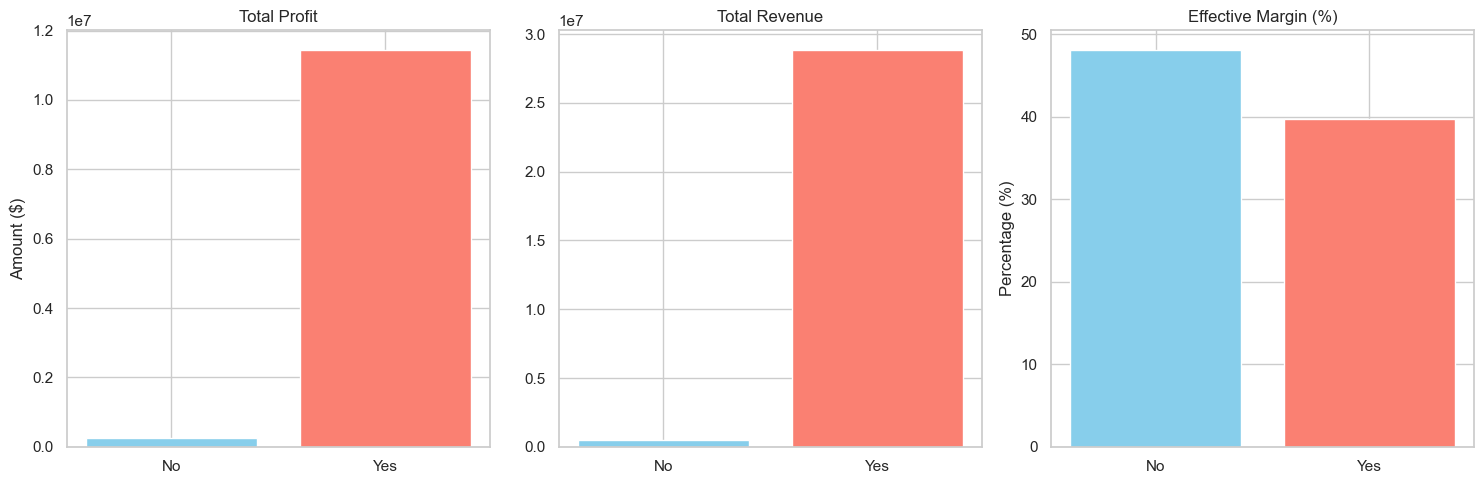

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['skyblue','salmon']

axes[0].bar(maintenance_metric.index,maintenance_metric['total_profit'], color = colors)
axes[0].set_title('Total Profit')
axes[0].set_ylabel('Amount ($)')

axes[1].bar(maintenance_metric.index,maintenance_metric['total_revenue'], color = colors)
axes[1].set_title('Total Revenue')

axes[2].bar(maintenance_metric.index,maintenance_metric['effective_margin'], color = colors)
axes[2].set_title('Effective Margin (%)')
axes[2].set_ylabel('Percentage (%)')

plt.tight_layout()

plt.show()

### Which countries are driving true profit? Rank the country column not just by total sales amount, but by average profit margin per order.

In [132]:
df['order_margin'] = (df['total_profit'] / df['sales_amount']) * 100
country_metric =df.groupby('country').agg(
    total_revenue = ('sales_amount','sum'),
    total_profit = ('total_profit','sum'),
    avg_margin_per_order = ('order_margin', 'mean'),
    total_orders = ('sales_amount','count')
).reset_index()

country_metric['profit_margin']= (country_metric['total_profit'] / country_metric['total_revenue']) * 100

country_ranked = country_metric.sort_values(by='avg_margin_per_order', ascending=False).reset_index(drop=True)

country_ranked['margin_rank'] = country_ranked.index + 1
country_ranked['sales_rank'] = country_ranked['total_revenue'].rank(ascending=False,method='min').astype(int)
country_ranked[['margin_rank', 'country', 'avg_margin_per_order', 'sales_rank', 'total_revenue', 'total_profit']]

,margin_rank,country,avg_margin_per_order,sales_rank,total_revenue,total_profit
0,1,Canada,55.620672,6,1977738,811661
1,2,United States,53.307691,1,9162327,3715394
2,3,France,52.234176,5,2643751,1041862
3,4,United Kingdom,51.876525,3,3391376,1342468
4,5,Germany,51.623349,4,2894066,1147605
5,6,n/a,51.313509,7,226820,84634
6,7,Australia,50.705433,2,9060172,3542133


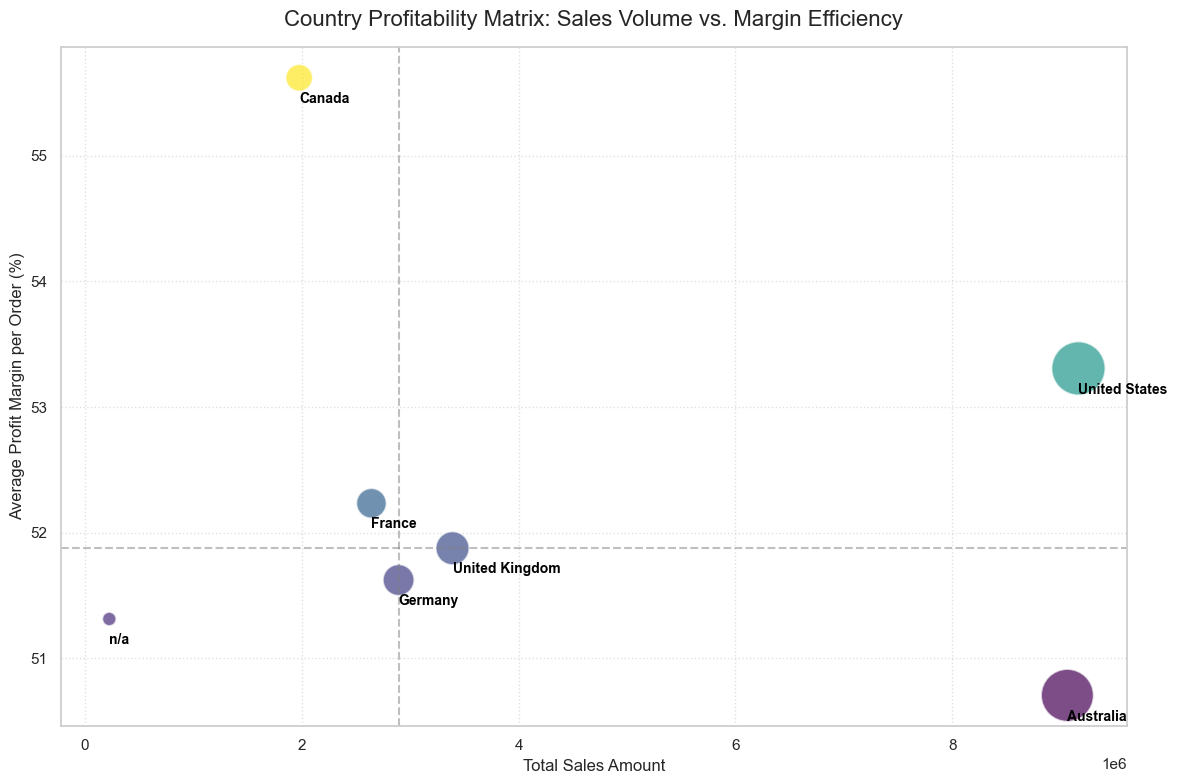

In [148]:
plt.figure(figsize=(12, 8))


sns.scatterplot(
    data=country_metric, 
    x='total_revenue', 
    y='avg_margin_per_order', 
    size='total_profit', 
    sizes=(100, 1500),
    hue='avg_margin_per_order',
    palette='viridis', 
    alpha=0.7,
    legend=False
)

for i in range(country_metric.shape[0]):
    plt.text(
        x=country_metric['total_revenue'][i], 
        y=country_metric['avg_margin_per_order'][i] - 0.2,
        s=country_metric['country'][i], 
        fontdict=dict(color='black', size=10, weight='bold')
    )

plt.title('Country Profitability Matrix: Sales Volume vs. Margin Efficiency', fontsize=16, pad=15)
plt.xlabel('Total Sales Amount', fontsize=12)
plt.ylabel('Average Profit Margin per Order (%)', fontsize=12)

plt.axvline(country_metric['total_revenue'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(country_metric['avg_margin_per_order'].median(), color='gray', linestyle='--', alpha=0.5)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

### Are there regional pricing inefficiencies? Do the same product_category items yield drastically different profit margins depending on the country they are sold in?

In [153]:
regional_metric = df.groupby(['country','category']).agg(
    total_revenue = ('sales_amount','sum'),
    total_profit = ('total_profit','sum')
)

regional_metric['effective_margin'] = (regional_metric['total_profit'] / regional_metric['total_revenue']) * 100

In [154]:
regional_metric

total_revenue  total_profit  effective_margin
country        category                                                  
Australia      Accessories         138567         87129         62.878607
               Bikes              8851429       3428417         38.732921
               Clothing             70176         26587         37.886172
Canada         Accessories         103393         64817         62.689931
               Bikes              1821196        723007         39.699571
               Clothing             53149         23837         44.849386
France         Accessories          63315         39752         62.784490
               Bikes              2553423        992257         38.859876
               Clothing             27013          9853         36.475031
Germany        Accessories          62133         39029         62.815251
               Bikes              2808337       1100771         39.196542
               Clothing             23596          7805         33.077640
United Kingdom Accessories          76547         48055         62.778424
               Bikes              3282624       1283065         39.086566
               Clothing             32205         11348         35.236764
United States  Accessories         248558        155911         62.726205
               Bikes              8787397       3504848         39.884940
               Clothing            126372         54635         43.233469
n/a            Accessories           7749          4817         62.162860
               Bikes               211866         77200         36.438126
               Clothing              7205          2617         36.321999